In [44]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [45]:
print(train.shape)

(3000888, 6)


In [46]:
print(train.info())


<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB
None


In [47]:
print(train.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [48]:
print(train.describe())

                 id     store_nbr         sales   onpromotion
count  3.000888e+06  3.000888e+06  3.000888e+06  3.000888e+06
mean   1.500444e+06  2.750000e+01  3.577757e+02  2.602770e+00
std    8.662819e+05  1.558579e+01  1.101998e+03  1.221888e+01
min    0.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00
25%    7.502218e+05  1.400000e+01  0.000000e+00  0.000000e+00
50%    1.500444e+06  2.750000e+01  1.100000e+01  0.000000e+00
75%    2.250665e+06  4.100000e+01  1.958473e+02  0.000000e+00
max    3.000887e+06  5.400000e+01  1.247170e+05  7.410000e+02


In [49]:
print(train.nunique())

id             3000888
date              1684
store_nbr           54
family              33
sales           379610
onpromotion        362
dtype: int64


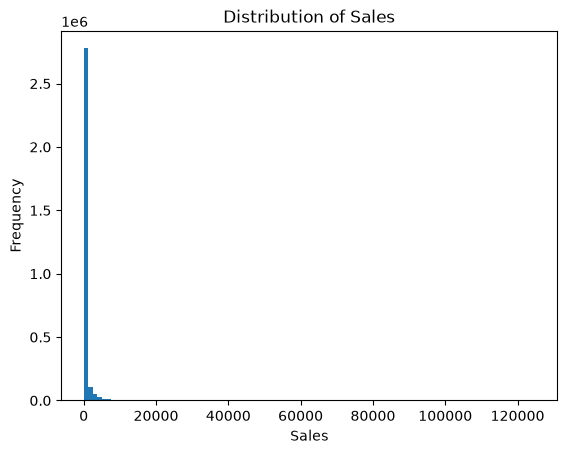

In [50]:
import matplotlib.pyplot as plt

plt.hist(train["sales"], bins=100)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

In [51]:
train["sales"].quantile([0.9, 0.95, 0.99, 0.999])

0.900      867.000000
0.950     1965.000000
0.990     5507.000000
0.999    12076.225548
Name: sales, dtype: float64

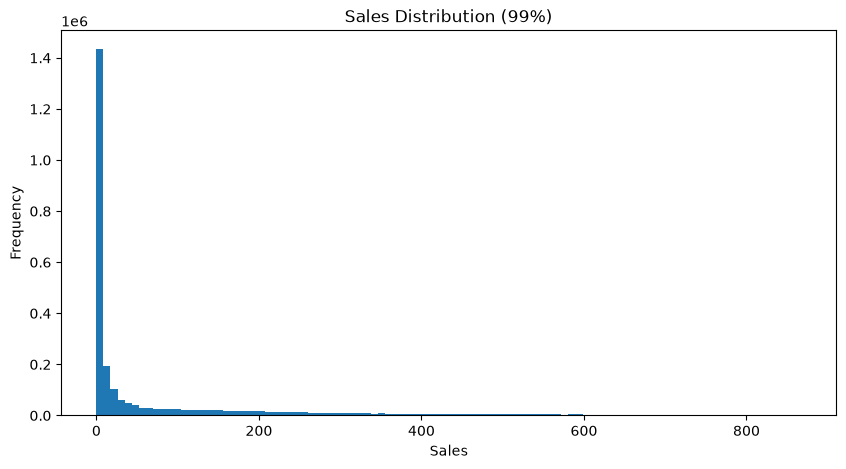

In [52]:
upper = train["sales"].quantile(0.9)

plt.figure(figsize=(10, 5))
plt.hist(
    train["sales"],
    bins=100,
    range=(0, upper)
)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution (99%)")
plt.show()

In [53]:
(train["onpromotion"] == 0).mean() * 100

np.float64(79.62839666125492)

In [54]:
train["onpromotion"].quantile([0.9, 0.95, 0.99, 0.999])

0.900      4.0
0.950     13.0
0.990     55.0
0.999    170.0
Name: onpromotion, dtype: float64

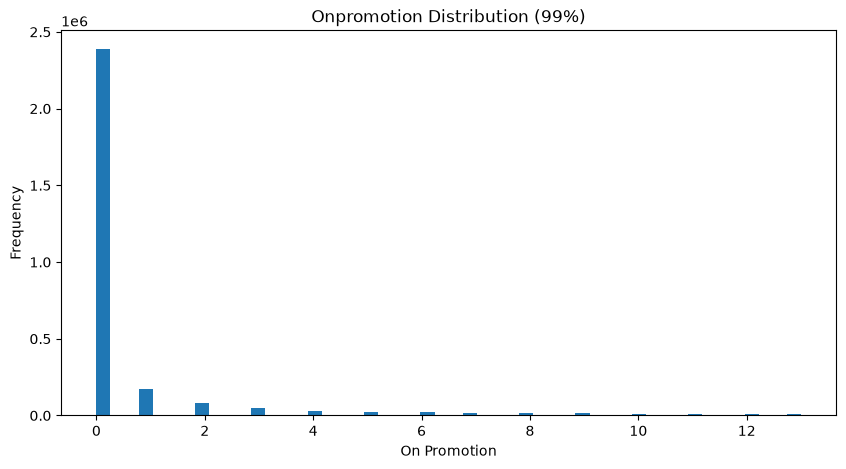

In [55]:
upper = train["onpromotion"].quantile(0.95)

plt.figure(figsize=(10, 5))
plt.hist(
    train["onpromotion"],
    bins=50,
    range=(0, upper)
)

plt.xlabel("On Promotion")
plt.ylabel("Frequency")
plt.title("Onpromotion Distribution (99%)")
plt.show()

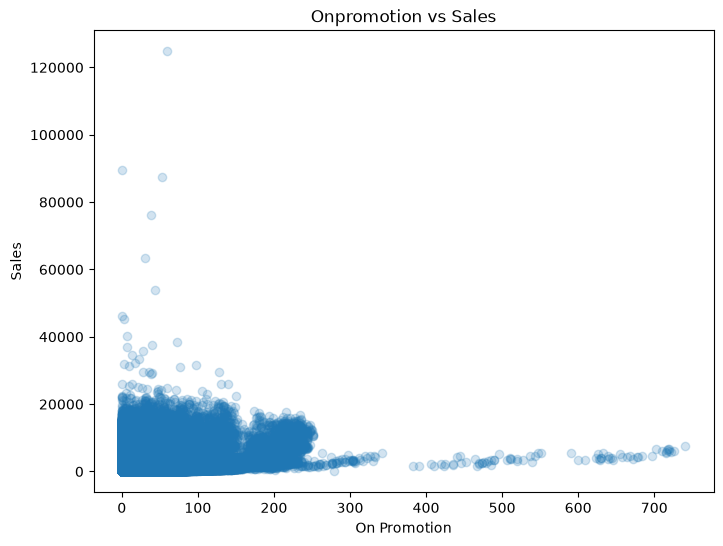

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(
    train["onpromotion"],
    train["sales"],
    alpha=0.2
)

plt.xlabel("On Promotion")
plt.ylabel("Sales")
plt.title("Onpromotion vs Sales")
plt.show()

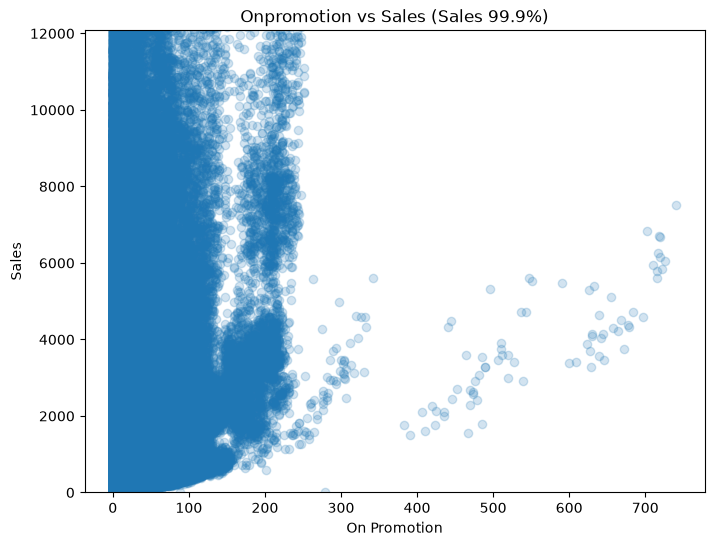

In [57]:
sales_upper = train["sales"].quantile(0.999)

plt.figure(figsize=(8, 6))

plt.scatter(
    train["onpromotion"],
    train["sales"],
    alpha=0.2
)

plt.ylim(0, sales_upper)

plt.xlabel("On Promotion")
plt.ylabel("Sales")
plt.title("Onpromotion vs Sales (Sales 99.9%)")
plt.show()

In [58]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [59]:
train = train.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

In [60]:
daily_sales = (
    train.groupby("date")["sales"]
    .sum()
    .reset_index()
)

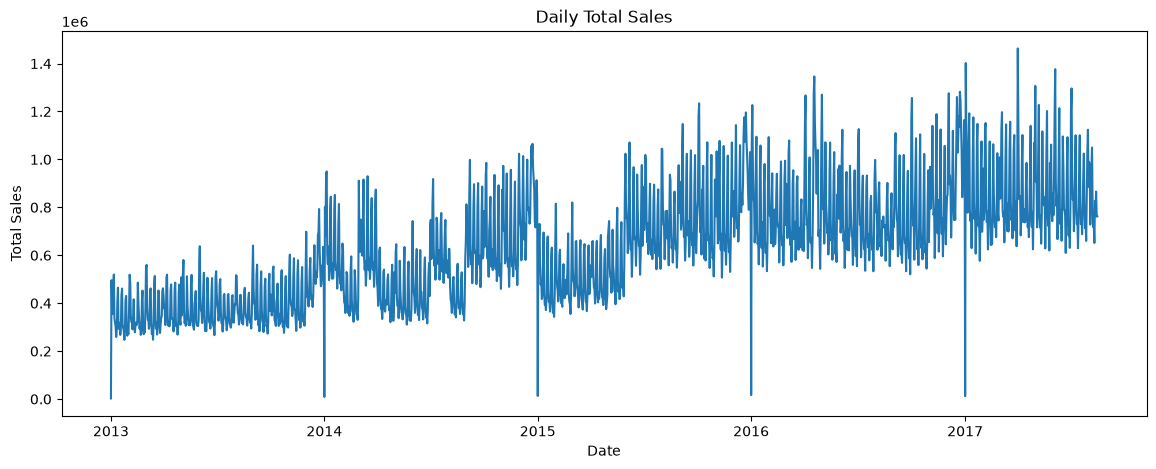

In [61]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Total Sales")
plt.show()

In [62]:
store_sales = (
    train.groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
46    4.189606e+07
48    3.593313e+07
51    3.291149e+07
8     3.049429e+07
50    2.865302e+07
11    2.832556e+07
7     2.695205e+07
9     2.640944e+07
6     2.518368e+07
24    2.376773e+07
2     2.155739e+07
39    2.025219e+07
37    1.997064e+07
27    1.918802e+07
4     1.890970e+07
38    1.886000e+07
40    1.839576e+07
28    1.838315e+07
17    1.803097e+07
31    1.774687e+07
34    1.709073e+07
43    1.639169e+07
5     1.559240e+07
36    1.532243e+07
41    1.499104e+07
33    1.417850e+07
1     1.414501e+07
18    1.325938e+07
19    1.304951e+07
20    1.292095e+07
23    1.165138e+07
15    1.145127e+07
25    1.142100e+07
14    1.138792e+07
53    1.121617e+07
54    1.105748e+07
16    1.098641e+07
12    1.065922e+07
13    1.052305e+07
29    9.725158e+06
10    9.613906e+06
21    9.255506e+06
42    8.945768e+06
26    7.755122e+06
35    7.676679e+06
30    7.382074e+06
32    5.951796e+06
22

In [63]:
top_stores = [44, 45, 47, 3]

store_daily = (
    train[train["store_nbr"].isin(top_stores)]
    .groupby(["date", "store_nbr"])["sales"]
    .sum()
    .reset_index()
)

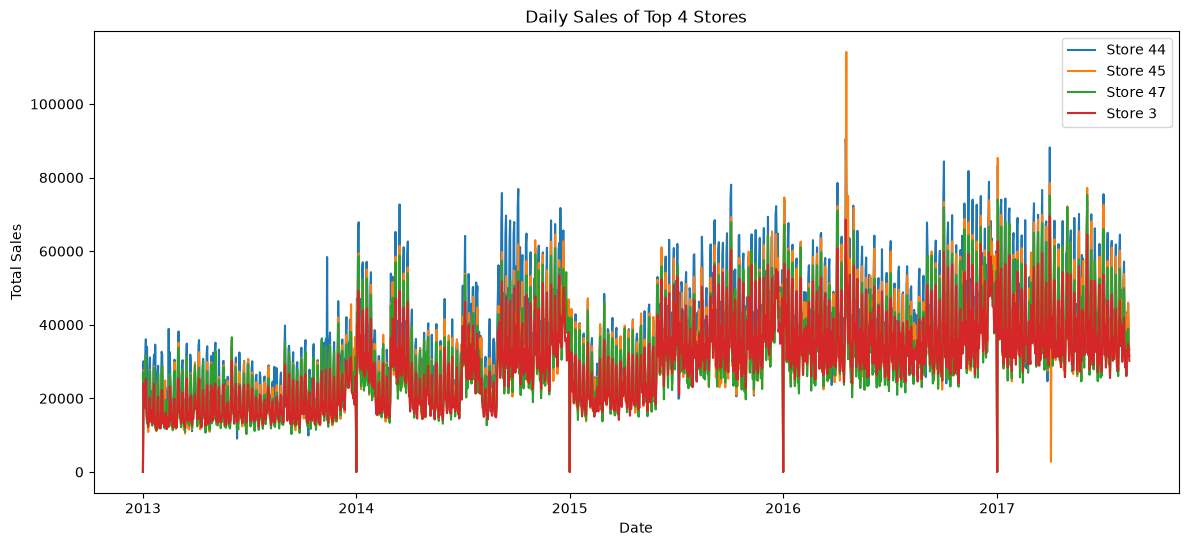

In [64]:
plt.figure(figsize=(14, 6))

for store in top_stores:
    data = store_daily[store_daily["store_nbr"] == store]
    plt.plot(data["date"], data["sales"], label=f"Store {store}")

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Sales of Top 4 Stores")
plt.legend()
plt.show()

In [65]:
family_sales = (
    train.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

family_sales

family
GROCERY I                     3.434627e+08
BEVERAGES                     2.169545e+08
PRODUCE                       1.227047e+08
CLEANING                      9.752129e+07
DAIRY                         6.448771e+07
BREAD/BAKERY                  4.213395e+07
POULTRY                       3.187600e+07
MEATS                         3.108647e+07
PERSONAL CARE                 2.459205e+07
DELI                          2.411032e+07
HOME CARE                     1.602274e+07
EGGS                          1.558830e+07
FROZEN FOODS                  1.407389e+07
PREPARED FOODS                8.799895e+06
LIQUOR,WINE,BEER              7.746640e+06
SEAFOOD                       2.015432e+06
GROCERY II                    1.962767e+06
HOME AND KITCHEN I            1.861491e+06
HOME AND KITCHEN II           1.520670e+06
CELEBRATION                   7.611770e+05
LINGERIE                      6.531140e+05
LADIESWEAR                    6.511590e+05
PLAYERS AND ELECTRONICS       5.626080e+05
AUTO

In [66]:
top4_families = family_sales.head(4).index
top8_families = family_sales.head(8).index

In [67]:
family_daily = (
    train[train["family"].isin(top8_families)]
    .groupby(["date", "family"])["sales"]
    .sum()
    .reset_index()
)

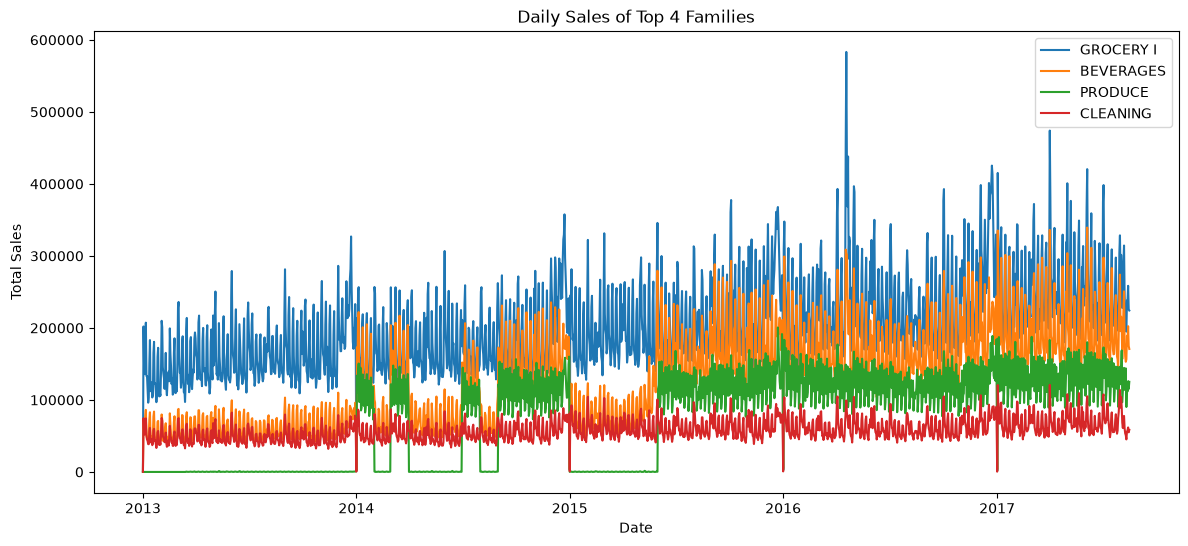

In [68]:
plt.figure(figsize=(14, 6))

for family in top4_families:
    data = family_daily[family_daily["family"] == family]
    plt.plot(data["date"], data["sales"], label=family)

plt.title("Daily Sales of Top 4 Families")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

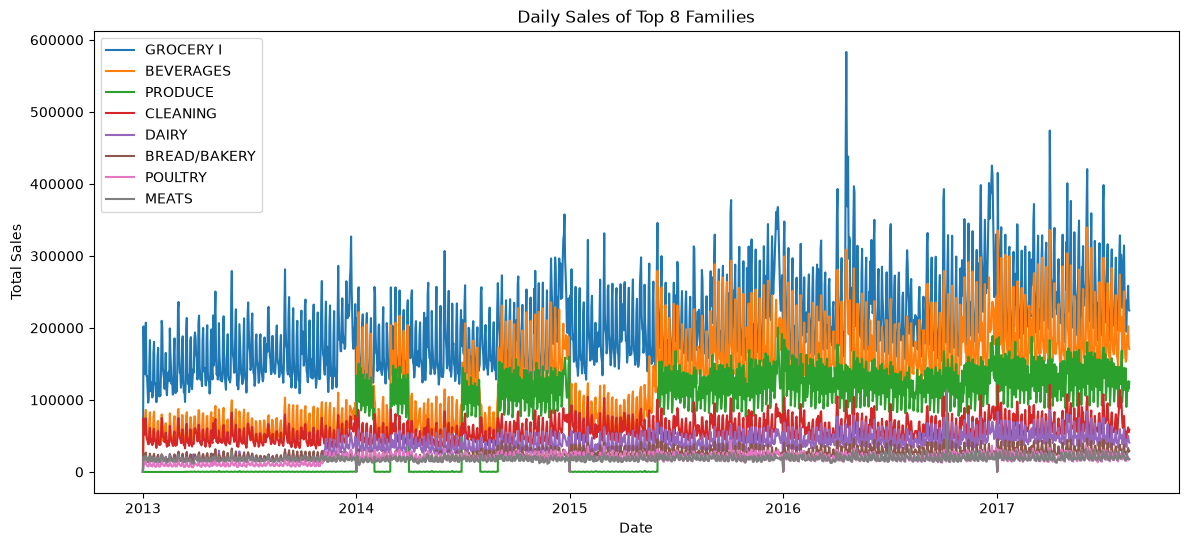

In [69]:
plt.figure(figsize=(14, 6))

for family in top8_families:
    data = family_daily[family_daily["family"] == family]
    plt.plot(data["date"], data["sales"], label=family)

plt.title("Daily Sales of Top 8 Families")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

In [70]:
set(test["store_nbr"]) - set(train["store_nbr"])
set(test["family"]) - set(train["family"])

set()

In [71]:
train["dayofweek"] = train["date"].dt.day_name()

train.groupby("dayofweek")["sales"].mean()

dayofweek
Friday       325.238138
Monday       346.544732
Saturday     433.336472
Sunday       463.085366
Thursday     283.540517
Tuesday      319.823843
Wednesday    332.909401
Name: sales, dtype: float64

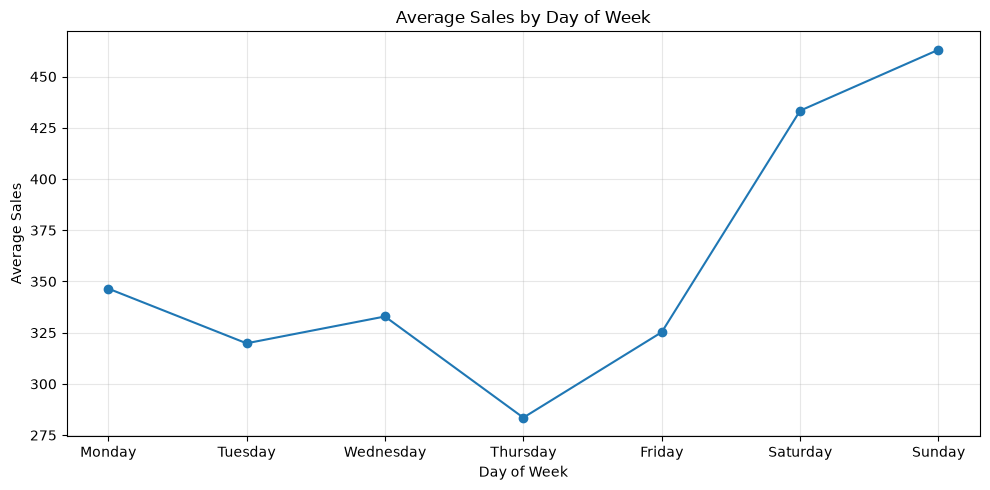

In [72]:
import matplotlib.pyplot as plt

# 요일별 평균 sales
weekday_sales = (
    train.groupby("dayofweek")["sales"]
    .mean()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

# 그래프
plt.figure(figsize=(10, 5))

plt.plot(
    weekday_sales.index,
    weekday_sales.values,
    marker="o"
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
import pandas as pd

# date 컬럼이 아직 datetime이 아니라면 변환
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

# 1. Train / Test 날짜 범위
print("Train 기간")
print("시작:", train["date"].min())
print("종료:", train["date"].max())

print("\nTest 기간")
print("시작:", test["date"].min())
print("종료:", test["date"].max())

# 2. 실제 포함된 날짜 수
train_dates = train["date"].drop_duplicates().sort_values()
test_dates = test["date"].drop_duplicates().sort_values()

print("\nTrain 고유 날짜 수:", train_dates.nunique())
print("Test 고유 날짜 수:", test_dates.nunique())

# 3. 예측 기간 확인
forecast_days = (test["date"].max() - test["date"].min()).days + 1
print("\n예측 기간:", forecast_days, "일")

# 4. 중간에 빠진 날짜 확인
expected_train_dates = pd.date_range(
    start=train["date"].min(),
    end=train["date"].max(),
    freq="D"
)

missing_train_dates = expected_train_dates.difference(train_dates)

print("\nTrain 누락 날짜 수:", len(missing_train_dates))
print("Train 누락 날짜:")
print(missing_train_dates)

expected_test_dates = pd.date_range(
    start=test["date"].min(),
    end=test["date"].max(),
    freq="D"
)

missing_test_dates = expected_test_dates.difference(test_dates)

print("\nTest 누락 날짜 수:", len(missing_test_dates))
print("Test 누락 날짜:")
print(missing_test_dates)

Train 기간
시작: 2013-01-01 00:00:00
종료: 2017-08-15 00:00:00

Test 기간
시작: 2017-08-16 00:00:00
종료: 2017-08-31 00:00:00

Train 고유 날짜 수: 1684
Test 고유 날짜 수: 16

예측 기간: 16 일

Train 누락 날짜 수: 4
Train 누락 날짜:
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[us]', freq=None)

Test 누락 날짜 수: 0
Test 누락 날짜:
DatetimeIndex([], dtype='datetime64[us]', freq='D')


In [74]:
print((train["sales"] == 0).mean())

(train["sales"] == 0).mean()
train.groupby("family")["sales"].apply(
    lambda x: (x == 0).mean()
).sort_values(ascending=False)

0.3129506999261552


family
BOOKS                         0.969550
BABY CARE                     0.941310
SCHOOL AND OFFICE SUPPLIES    0.740829
HOME APPLIANCES               0.735176
LADIESWEAR                    0.598465
MAGAZINES                     0.565387
PET SUPPLIES                  0.546153
HARDWARE                      0.478622
LAWN AND GARDEN               0.467846
PLAYERS AND ELECTRONICS       0.448865
CELEBRATION                   0.436340
HOME CARE                     0.409090
HOME AND KITCHEN II           0.347134
HOME AND KITCHEN I            0.346452
PRODUCE                       0.283551
BEAUTY                        0.262822
SEAFOOD                       0.193587
LIQUOR,WINE,BEER              0.178653
LINGERIE                      0.160465
AUTOMOTIVE                    0.127848
GROCERY II                    0.121129
FROZEN FOODS                  0.080914
PREPARED FOODS                0.080837
POULTRY                       0.080760
PERSONAL CARE                 0.080650
GROCERY I         

In [75]:
holidays = pd.read_csv("../data/holidays_events.csv")
print(holidays.head())
print(holidays.isnull().sum())

         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


In [76]:
print(holidays.info())

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         350 non-null    str  
 1   type         350 non-null    str  
 2   locale       350 non-null    str  
 3   locale_name  350 non-null    str  
 4   description  350 non-null    str  
 5   transferred  350 non-null    bool 
dtypes: bool(1), str(5)
memory usage: 14.1 KB
None


In [77]:
# 같은 날짜가 여러 번 등장하는지 확인
holidays[
    holidays.duplicated(subset="date", keep=False)
].sort_values("date")

,date,type,locale,locale_name,description,transferred
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False
10,2012-07-03,Holiday,Local,Santo Domingo,Fundacion de Santo Domingo,False
11,2012-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
...,...,...,...,...,...,...
319,2017-07-03,Holiday,Local,Santo Domingo,Fundacion de Santo Domingo,False
341,2017-12-08,Holiday,Local,Loja,Fundacion de Loja,False
342,2017-12-08,Transfer,Local,Quito,Traslado Fundacion de Quito,False
344,2017-12-22,Holiday,Local,Salinas,Cantonizacion de Salinas,False


In [78]:
# 같은 날짜가 여러 번 등장하는지 확인
holidays[
    holidays.duplicated(subset="date", keep=False)
].sort_values("description")

,date,type,locale,locale_name,description,transferred
179,2015-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
261,2016-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
11,2012-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
118,2014-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
318,2017-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
...,...,...,...,...,...,...
250,2016-05-12,Event,National,Ecuador,Terremoto Manabi+26,False
225,2016-04-21,Event,National,Ecuador,Terremoto Manabi+5,False
265,2016-07-24,Transfer,Local,Guayaquil,Traslado Fundacion de Guayaquil,False
342,2017-12-08,Transfer,Local,Quito,Traslado Fundacion de Quito,False


In [79]:
date_grouped = (
    holidays
    .groupby("date")
    .agg(
        count=("date", "size"),
        type=("type", list),
        locale=("locale", list),
        locale_name=("locale_name", list),
        description=("description", list),
        transferred=("transferred", list)
    )
)

# 이벤트가 2개 이상 있는 날짜만
date_grouped[date_grouped["count"] > 1]

,count,type,locale,locale_name,description,transferred
date,,,,,,
2012-06-25,3,"[Holiday, Holiday, Holiday]","[Regional, Local, Local]","[Imbabura, Latacunga, Machala]","[Provincializacion de Imbabura, Cantonizacion ...","[False, False, False]"
2012-07-03,2,"[Holiday, Holiday]","[Local, Local]","[Santo Domingo, El Carmen]","[Fundacion de Santo Domingo, Cantonizacion de ...","[False, False]"
2012-12-22,2,"[Holiday, Additional]","[Local, National]","[Salinas, Ecuador]","[Cantonizacion de Salinas, Navidad-3]","[False, False]"
2012-12-24,2,"[Bridge, Additional]","[National, National]","[Ecuador, Ecuador]","[Puente Navidad, Navidad-1]","[False, False]"
2012-12-31,2,"[Bridge, Additional]","[National, National]","[Ecuador, Ecuador]","[Puente Primer dia del ano, Primer dia del ano-1]","[False, False]"
2013-05-12,2,"[Holiday, Event]","[Local, National]","[Puyo, Ecuador]","[Cantonizacion del Puyo, Dia de la Madre]","[False, False]"
2013-06-25,3,"[Holiday, Holiday, Holiday]","[Regional, Local, Local]","[Imbabura, Machala, Latacunga]","[Provincializacion de Imbabura, Fundacion de M...","[False, False, False]"
2013-07-03,2,"[Holiday, Holiday]","[Local, Local]","[El Carmen, Santo Domingo]","[Cantonizacion de El Carmen, Fundacion de Sant...","[False, False]"
2013-12-22,2,"[Additional, Holiday]","[National, Local]","[Ecuador, Salinas]","[Navidad-3, Cantonizacion de Salinas]","[False, False]"


In [80]:
description_grouped = (
    holidays
    .groupby("description")
    .agg(
        count=("description", "size"),
        dates=("date", list),
        type=("type", "unique"),
        locale=("locale", "unique"),
        locale_name=("locale_name", "unique")
    )
)

description_grouped[description_grouped["count"] > 1]

,count,dates,type,locale,locale_name
description,,,,,
Batalla de Pichincha,5,"[2013-05-24, 2014-05-24, 2015-05-24, 2016-05-2...",[Holiday],[National],[Ecuador]
Black Friday,3,"[2014-11-28, 2015-11-27, 2016-11-25]",[Event],[National],[Ecuador]
Cantonizacion de Cayambe,6,"[2012-07-23, 2013-07-23, 2014-07-23, 2015-07-2...",[Holiday],[Local],[Cayambe]
Cantonizacion de El Carmen,6,"[2012-07-03, 2013-07-03, 2014-07-03, 2015-07-0...",[Holiday],[Local],[El Carmen]
Cantonizacion de Guaranda,6,"[2012-06-23, 2013-06-23, 2014-06-23, 2015-06-2...",[Holiday],[Local],[Guaranda]
Cantonizacion de Latacunga,6,"[2012-06-25, 2013-06-25, 2014-06-25, 2015-06-2...",[Holiday],[Local],[Latacunga]
Cantonizacion de Libertad,6,"[2012-04-14, 2013-04-14, 2014-04-14, 2015-04-1...",[Holiday],[Local],[Libertad]
Cantonizacion de Quevedo,6,"[2012-10-07, 2013-10-07, 2014-10-07, 2015-10-0...",[Holiday],[Local],[Quevedo]
Cantonizacion de Riobamba,6,"[2012-04-21, 2013-04-21, 2014-04-21, 2015-04-2...",[Holiday],[Local],[Riobamba]


In [81]:
holidays["date"] = pd.to_datetime(holidays["date"])

In [82]:
holidays.sort_values("date")[
    ["date", "type", "locale", "locale_name", "description", "transferred"]
].head(50)

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False


In [83]:
holidays["month_day"] = holidays["date"].dt.strftime("%m-%d")

holidays.groupby("month_day").agg(
    count=("description", "count"),
    descriptions=("description", lambda x: list(x.unique())),
    types=("type", lambda x: list(x.unique()))
).sort_index()

,count,descriptions,types
month_day,,,
01-01,5,[Primer dia del ano],[Holiday]
01-02,2,"[Puente Primer dia del ano, Traslado Primer di...","[Bridge, Transfer]"
01-05,1,[Recupero puente Navidad],[Work Day]
01-10,1,[Recupero Puente Primer dia del ano],[Work Day]
01-12,1,[Recupero puente primer dia del ano],[Work Day]
...,...,...,...
12-23,6,[Navidad-2],[Additional]
12-24,7,"[Puente Navidad, Navidad-1]","[Bridge, Additional]"
12-25,6,[Navidad],[Holiday]


In [84]:
month_day_summary = holidays.groupby("month_day").agg(
    count=("description", "count"),
    descriptions=("description", lambda x: list(x.unique())),
    types=("type", lambda x: list(x.unique()))
)

month_day_summary[
    month_day_summary["count"] >= 5
].sort_values("count", ascending=False)

,count,descriptions,types
month_day,,,
06-25,19,"[Provincializacion de Imbabura, Cantonizacion ...","[Holiday, Event]"
07-03,12,"[Fundacion de Santo Domingo, Cantonizacion de ...",[Holiday]
12-22,12,"[Cantonizacion de Salinas, Navidad-3]","[Holiday, Additional]"
05-12,8,"[Cantonizacion del Puyo, Dia de la Madre, Terr...","[Holiday, Event]"
04-14,7,"[Cantonizacion de Libertad, Viernes Santo]",[Holiday]
04-21,7,"[Cantonizacion de Riobamba, Terremoto Manabi+5]","[Holiday, Event]"
12-26,7,"[Navidad+1, Puente Navidad]","[Additional, Bridge]"
11-12,7,"[Independencia de Ambato, Recupero Puente Dia ...","[Holiday, Work Day]"
12-08,7,"[Fundacion de Loja, Traslado Fundacion de Quito]","[Holiday, Transfer]"


In [85]:
def simplify_holiday(desc):
    if "Navidad" in desc:
        return "Christmas"
    elif "Primer dia del ano" in desc:
        return "New Year"
    elif "Dia de la Madre" in desc:
        return "Mothers Day"
    elif "Dia del Trabajo" in desc:
        return "Labor Day"
    elif "Viernes Santo" in desc:
        return "Good Friday"
    elif "Black Friday" in desc:
        return "Black Friday"
    elif "Cyber Monday" in desc:
        return "Cyber Monday"
    elif "Carnaval" in desc:
        return "Carnival"
    elif "Dia de Difuntos" in desc:
        return "Day of the Dead"
    elif "Batalla de Pichincha" in desc:
        return "Pichincha Day"
    elif "Mundial" in desc:
        return "World Cup"
    elif "Terremoto" in desc:
        return "Earthquake Event"
    elif "Fundacion" in desc:
        return "City Foundation"
    elif "Cantonizacion" in desc:
        return "Local Anniversary"
    elif "Provincializacion" in desc:
        return "Provincial Anniversary"
    elif "Independencia" in desc or "Primer Grito" in desc:
        return "Independence Day"
    else:
        return "Other"

In [ ]:
holiday_by_date = holidays.groupby("date").agg(
    event_count=("description", "count"),
    event_groups=("event_group", lambda x: list(x.unique())),
    descriptions=("description", lambda x: list(x.unique())),
    types=("type", lambda x: list(x.unique())),
    locales=("locale", lambda x: list(x.unique())),
    locale_names=("locale_name", lambda x: list(x.unique()))
).reset_index()

holiday_by_date.sort_values("date").head(50)

,date,event_count,event_groups,descriptions,types,locales,locale_names
0,2012-03-02,1,[City Foundation],[Fundacion de Manta],[Holiday],[Local],[Manta]
1,2012-04-01,1,[Provincial Anniversary],[Provincializacion de Cotopaxi],[Holiday],[Regional],[Cotopaxi]
2,2012-04-12,1,[City Foundation],[Fundacion de Cuenca],[Holiday],[Local],[Cuenca]
3,2012-04-14,1,[Local Anniversary],[Cantonizacion de Libertad],[Holiday],[Local],[Libertad]
4,2012-04-21,1,[Local Anniversary],[Cantonizacion de Riobamba],[Holiday],[Local],[Riobamba]
5,2012-05-12,1,[Local Anniversary],[Cantonizacion del Puyo],[Holiday],[Local],[Puyo]
6,2012-06-23,1,[Local Anniversary],[Cantonizacion de Guaranda],[Holiday],[Local],[Guaranda]
7,2012-06-25,3,"[Provincial Anniversary, Local Anniversary, Ci...","[Provincializacion de Imbabura, Cantonizacion ...",[Holiday],"[Regional, Local]","[Imbabura, Latacunga, Machala]"
8,2012-07-03,2,"[City Foundation, Local Anniversary]","[Fundacion de Santo Domingo, Cantonizacion de ...",[Holiday],[Local],"[Santo Domingo, El Carmen]"
9,2012-07-23,1,[Local Anniversary],[Cantonizacion de Cayambe],[Holiday],[Local],[Cayambe]


In [ ]:
holiday_by_event = holidays.groupby("event_group").agg(
    count=("date", "count"),
    dates=("date", lambda x: list(x.sort_values())),
    descriptions=("description", lambda x: list(x.unique())),
    types=("type", lambda x: list(x.unique())),
    locales=("locale", lambda x: list(x.unique()))
).reset_index()

holiday_by_event.sort_values("count", ascending=False)

,event_group,count,dates,descriptions,types,locales
3,City Foundation,80,"[2012-03-02 00:00:00, 2012-04-12 00:00:00, 201...","[Fundacion de Manta, Fundacion de Cuenca, Fund...","[Holiday, Additional, Transfer]",[Local]
9,Local Anniversary,54,"[2012-04-14 00:00:00, 2012-04-21 00:00:00, 201...","[Cantonizacion de Libertad, Cantonizacion de R...",[Holiday],[Local]
7,Independence Day,41,"[2012-08-10 00:00:00, 2012-10-09 00:00:00, 201...","[Primer Grito de Independencia, Independencia ...","[Holiday, Transfer]","[National, Local]"
2,Christmas,40,"[2012-12-21 00:00:00, 2012-12-22 00:00:00, 201...","[Navidad-4, Navidad-3, Navidad-2, Puente Navid...","[Additional, Bridge, Holiday, Work Day]",[National]
5,Earthquake Event,31,"[2016-04-16 00:00:00, 2016-04-17 00:00:00, 201...","[Terremoto Manabi, Terremoto Manabi+1, Terremo...",[Event],[National]
12,Other,30,"[2012-11-02 00:00:00, 2013-01-12 00:00:00, 201...","[Dia de Difuntos, Recupero puente primer dia d...","[Holiday, Work Day, Event, Transfer, Bridge]",[National]
13,Provincial Anniversary,24,"[2012-04-01 00:00:00, 2012-06-25 00:00:00, 201...","[Provincializacion de Cotopaxi, Provincializac...",[Holiday],[Regional]
11,New Year,14,"[2012-12-31 00:00:00, 2012-12-31 00:00:00, 201...","[Puente Primer dia del ano, Primer dia del ano...","[Bridge, Additional, Holiday, Work Day, Transfer]",[National]
1,Carnival,10,"[2013-02-11 00:00:00, 2013-02-12 00:00:00, 201...",[Carnaval],[Holiday],[National]
10,Mothers Day,10,"[2013-05-11 00:00:00, 2013-05-12 00:00:00, 201...","[Dia de la Madre-1, Dia de la Madre]","[Additional, Event]",[National]


In [ ]:
test_start = test["date"].min()
test_end = test["date"].max()

test_holidays = holidays[
    (holidays["date"] >= test_start) &
    (holidays["date"] <= test_end)
].sort_values("date")

test_holidays[
    ["date", "type", "locale", "locale_name", "description", "event_group", "transferred"]
]

,date,type,locale,locale_name,description,event_group,transferred
327,2017-08-24,Holiday,Local,Ambato,Fundacion de Ambato,City Foundation,False


In [87]:
holidays.columns

Index(['date', 'type', 'locale', 'locale_name', 'description', 'transferred',
       'month_day'],
      dtype='str')